# CelebA Face Crop for ArcFace

Tight crop of CelebA aligned face images using affine (similarity) transform based on 5-point facial landmarks.
Output: 112×112 images compatible with ArcFace input.

In [1]:
import os
import zipfile
from pathlib import Path

import cv2
import numpy as np
from skimage.transform import SimilarityTransform
from tqdm.auto import tqdm

/Users/szymonszafraniec/Documents/study/ai_sem3/biometrics/biometrics/face_authorization/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
DATA_DIR = Path("data")
LANDMARKS_PATH = DATA_DIR / "list_landmarks_align_celeba.txt"
ZIP_PATH = DATA_DIR / "img_align_celeba.zip"
OUTPUT_DIR = DATA_DIR / "processed" / "cropped"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ARCFACE_IMAGE_SIZE = (112, 112)

# ArcFace standard reference landmarks for 112x112 input
ARCFACE_REF_LANDMARKS = np.array([
    [38.2946, 51.6963],  # left eye
    [73.5318, 51.5014],  # right eye
    [56.0252, 71.7366],  # nose
    [41.5493, 92.3655],  # left mouth corner
    [70.7299, 92.2041],  # right mouth corner
], dtype=np.float64)

# Set to None to process all images, or an integer for debugging
MAX_IMAGES = None

## Parse landmarks

In [3]:
def parse_landmarks(path: Path) -> dict[str, np.ndarray]:
    """Parse CelebA landmark file into {filename: (5,2) ndarray} dict."""
    landmarks = {}
    with open(path) as f:
        n_images = int(f.readline().strip())
        f.readline()  # skip header line
        for line in f:
            parts = line.split()
            filename = parts[0]
            coords = np.array([int(x) for x in parts[1:]], dtype=np.float64).reshape(5, 2)
            landmarks[filename] = coords
    print(f"Parsed {len(landmarks)} landmark entries (expected {n_images})")
    return landmarks

landmarks = parse_landmarks(LANDMARKS_PATH)

Parsed 202599 landmark entries (expected 202599)


## Crop function

In [4]:
def align_face(img: np.ndarray, src_landmarks: np.ndarray) -> np.ndarray:
    """Crop and align a face using similarity transform from source to ArcFace reference landmarks."""
    tform = SimilarityTransform()
    tform.estimate(src_landmarks, ARCFACE_REF_LANDMARKS)
    M = tform.params[0:2, :]
    aligned = cv2.warpAffine(img, M, ARCFACE_IMAGE_SIZE, borderValue=0.0)
    return aligned

## Process all images

In [5]:
skipped = []

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    image_names = sorted(
        name for name in zf.namelist()
        if name.lower().endswith(".jpg") and not name.startswith("__MACOSX")
    )
    if MAX_IMAGES is not None:
        image_names = image_names[:MAX_IMAGES]

    for name in tqdm(image_names, desc="Cropping faces"):
        filename = os.path.basename(name)
        if filename not in landmarks:
            skipped.append(filename)
            continue

        img_bytes = zf.read(name)
        img = cv2.imdecode(np.frombuffer(img_bytes, np.uint8), cv2.IMREAD_COLOR)
        if img is None:
            skipped.append(filename)
            continue

        aligned = align_face(img, landmarks[filename])

        stem = Path(filename).stem
        out_path = OUTPUT_DIR / f"{stem}_cropped.jpg"
        cv2.imwrite(str(out_path), aligned)

print(f"Done. Processed {len(image_names) - len(skipped)} images.")
if skipped:
    print(f"Skipped {len(skipped)} images: {skipped[:10]}...")

Cropping faces:   0%|          | 0/202599 [00:00<?, ?it/s]/var/folders/xk/xf36yp7n4tdcbbx3lm248x7c0000gn/T/ipykernel_22177/193545000.py:4: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(src_landmarks, ARCFACE_REF_LANDMARKS)
Cropping faces:   0%|          | 946/202599 [00:00<01:08, 2954.48it/s]/Users/szymonszafraniec/Documents/study/ai_sem3/biometrics/biometrics/face_authorization/.venv/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
Cropping faces: 100%|██████████| 202599/202599 [01:11<00:00, 2841.31it/s]

Done. Processed 202599 images.


## Verification

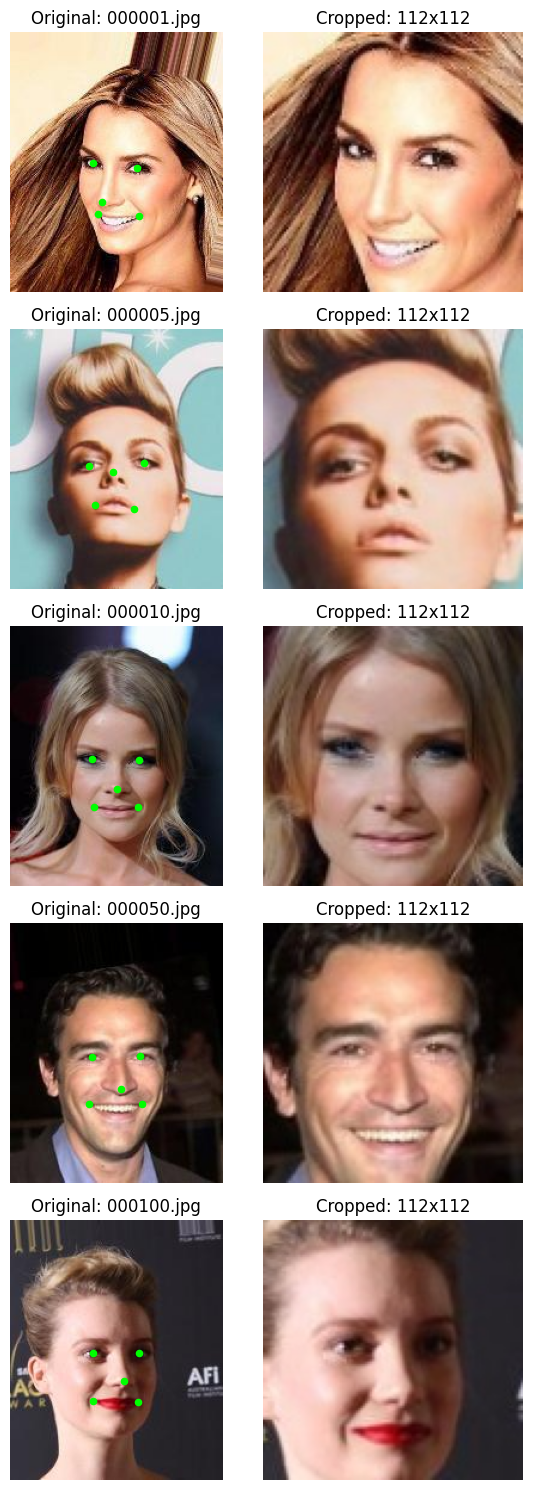

In [6]:
import matplotlib.pyplot as plt
import random

sample_files = ["000001.jpg", "000005.jpg", "000010.jpg", "000050.jpg", "000100.jpg"]

fig, axes = plt.subplots(len(sample_files), 2, figsize=(6, 3 * len(sample_files)))

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zip_entries = {os.path.basename(n): n for n in zf.namelist() if n.lower().endswith(".jpg")}
    for i, filename in enumerate(sample_files):
        # Original image with landmarks
        img_bytes = zf.read(zip_entries[filename])
        orig = cv2.imdecode(np.frombuffer(img_bytes, np.uint8), cv2.IMREAD_COLOR)
        orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

        lm = landmarks[filename]
        axes[i, 0].imshow(orig_rgb)
        axes[i, 0].scatter(lm[:, 0], lm[:, 1], c="lime", s=20, zorder=5)
        axes[i, 0].set_title(f"Original: {filename}")
        axes[i, 0].axis("off")

        # Cropped image
        stem = Path(filename).stem
        cropped = cv2.imread(str(OUTPUT_DIR / f"{stem}_cropped.jpg"))
        cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
        axes[i, 1].imshow(cropped_rgb)
        axes[i, 1].set_title(f"Cropped: {cropped_rgb.shape[1]}x{cropped_rgb.shape[0]}")
        axes[i, 1].axis("off")

plt.tight_layout()
plt.show()